# Diagnostic de Défauts Moteur CC 12V — Classification Binaire
# Normal vs Surcharge — Évaluation Robuste (LOO + SMOTE)

---

**Problème identifié sur la version précédente** :
- Dataset trop petit (35 échantillons) → split 80/20 donne ~7 points de test
- 1 seul échantillon Normal dans le jeu de test → scores non significatifs
- F1=1.0 obtenu sur 1 point ≠ preuve de généralisation

**Solutions implémentées dans ce notebook** :
1. **Leave-One-Out (LOO)** — chaque échantillon est tour à tour le jeu de test (35 évaluations)
2. **SMOTE** — suréchantillonnage synthétique de la classe Normal appliqué *à l'intérieur* des plis pour éviter toute fuite de données
3. **Pipeline scikit-learn** — SMOTE + StandardScaler + Modèle encapsulés pour une évaluation propre

---

## Table des matières

1. Contexte et corrections méthodologiques
2. Installation des dépendances
3. Chargement du dataset
4. Extraction des caractéristiques
5. Analyse du déséquilibre de classes
6. Stratégie d'évaluation : LOO + SMOTE dans un Pipeline
7. Entraînement et évaluation LOO
8. Analyse des résultats
9. Exportation du meilleur modèle pour ESP32

---
## 1. Contexte et corrections méthodologiques

### Pourquoi le split 80/20 était inadapté

| Problème | Impact |
|----------|--------|
| 35 échantillons totaux | Jeu de test de ~7 points seulement |
| 5 Normal vs 30 Surcharge | ~1 Normal dans le test → F1 basé sur 1 point |
| Variance extrême | Changer `random_state` suffit à inverser le classement |
| SMOTE appliqué avant split | Fuite de données synthétiques dans le test |

### Solution : Leave-One-Out (LOO)

```
Pour i = 1 à 35 :
    Test  = échantillon i  (1 seul point)
    Train = les 34 autres  (avec SMOTE appliqué uniquement ici)
    → Prédiction sur i
Résultat : 35 prédictions indépendantes → métriques globales fiables
```

LOO est la méthode de référence pour les petits datasets car il **utilise au maximum
les données disponibles** et produit une estimation presque sans biais.

### SMOTE dans le Pipeline (pas avant)

```
❌ MAUVAIS : SMOTE global → split → évaluation (fuite)
✅ CORRECT : for each fold → SMOTE(train_fold) → fit → predict(test_fold)
```

En encapsulant SMOTE dans un `Pipeline`, scikit-learn garantit que les échantillons
synthétiques ne sont jamais "vus" lors de l'évaluation.

---
## 2. Installation des dépendances

In [1]:
# Décommenter si exécution dans Google Colab :
%pip install xgboost m2cgen scikit-learn pandas numpy matplotlib seaborn scipy imbalanced-learn -q

Note: you may need to restart the kernel to use updated packages.


---
## 3. Chargement du dataset

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# ============================================================
# CONFIGURATION
# ============================================================
#!git clone https://github.com/ibarram/ITSC.git
# DATASET_ROOT = 'ITSC/dataset/Cropped_Signals_SF/Cropped_Signals_SF'
DATASET_ROOT = 'dataset/Cropped_Signals_SF/Cropped_Signals_SF'

# ============================================================
# REMAPPING BINAIRE : Normal (0) vs Surcharge (1)
# ============================================================
CLASS_MAPPING = {
    'SC_HLT':      'Normal',
    'SC_A1_B0_C0': 'Surcharge', 'SC_A2_B0_C0': 'Surcharge',
    'SC_A0_B1_C0': 'Surcharge', 'SC_A0_B2_C0': 'Surcharge',
    'SC_A0_B0_C1': 'Surcharge', 'SC_A0_B0_C2': 'Surcharge',
    # Niveaux 3-4 (court-circuit) : exclus
}

LABEL_TO_INT = {'Normal': 0, 'Surcharge': 1}
CLASS_NAMES  = ['Normal', 'Surcharge']
SENSOR_NAMES = ['Courant', 'Tension', 'Vitesse']

print("=" * 60)
print("CHARGEMENT DU DATASET")
print("=" * 60)

all_signals = []
dataset_path = Path(DATASET_ROOT)

for class_dir in sorted(dataset_path.iterdir()):
    if not class_dir.is_dir() or class_dir.name.startswith('.'):
        continue
    label = CLASS_MAPPING.get(class_dir.name)
    if label is None:
        continue
    for csv_file in sorted(class_dir.glob('*.csv')):
        signal = pd.read_csv(csv_file, header=None).values.astype(np.float32)
        all_signals.append((signal, label))

labels_list = [s[1] for s in all_signals]
for cls in CLASS_NAMES:
    count = labels_list.count(cls)
    print(f"  {cls:12s} : {count:3d} echantillons  ({count/len(labels_list)*100:.1f}%)")
print(f"  {'Total':12s} : {len(all_signals):3d} echantillons")

CHARGEMENT DU DATASET
  Normal       :   5 echantillons  (14.3%)
  Surcharge    :  30 echantillons  (85.7%)
  Total        :  35 echantillons


---
## 4. Extraction des caractéristiques

45 caractéristiques (15 par capteur × 3 capteurs) identiques au notebook précédent.

In [3]:
from scipy.stats import kurtosis, skew

def extract_features(signal):
    features = []
    n = signal.shape[0]
    for sensor in range(signal.shape[1]):
        x = signal[:, sensor]
        # Temporelles
        mean_val  = np.mean(x)
        std_val   = np.std(x)
        rms_val   = np.sqrt(np.mean(x**2))
        max_val   = np.max(x)
        min_val   = np.min(x)
        ptp_val   = max_val - min_val
        kurt_val  = kurtosis(x)
        skew_val  = skew(x)
        mad_val   = np.mean(np.abs(np.diff(x)))
        iqr_val   = np.percentile(x, 75) - np.percentile(x, 25)
        # Frequentielles
        spectrum  = np.abs(np.fft.fft(x))[:n // 2]
        freqs     = np.fft.fftfreq(n, d=1.0/1000)[:n // 2]
        s_energy  = np.sum(spectrum**2)
        dom_freq  = freqs[np.argmax(spectrum)]
        mean_freq = np.sum(freqs * spectrum) / (np.sum(spectrum) + 1e-10)
        spec_std  = np.std(spectrum)
        peak_r    = np.max(spectrum) / (np.sum(spectrum) + 1e-10)
        features.extend([mean_val, std_val, rms_val, max_val, min_val, ptp_val,
                          kurt_val, skew_val, mad_val, iqr_val,
                          s_energy, dom_freq, mean_freq, spec_std, peak_r])
    return np.array(features)

TEMPORAL_FEATS = ['Mean','Std','RMS','Max','Min','PeakToPeak',
                  'Kurtosis','Skewness','MAD','IQR']
SPECTRAL_FEATS = ['SpectralEnergy','DominantFreq','MeanFreq',
                  'SpectralStd','SpectralPeakRatio']
feature_names  = [f'{s}_{f}' for s in SENSOR_NAMES
                              for f in TEMPORAL_FEATS + SPECTRAL_FEATS]

X = np.array([extract_features(sig) for sig, _ in all_signals])
y = np.array([LABEL_TO_INT[lbl] for _, lbl in all_signals])

print(f"Matrice X : {X.shape}")
print(f"Vecteur y : {np.bincount(y)}  (0=Normal, 1=Surcharge)")

Matrice X : (35, 45)
Vecteur y : [ 5 30]  (0=Normal, 1=Surcharge)


---
## 5. Analyse du déséquilibre de classes

Visualisation du problème de déséquilibre et explication de l'effet SMOTE.

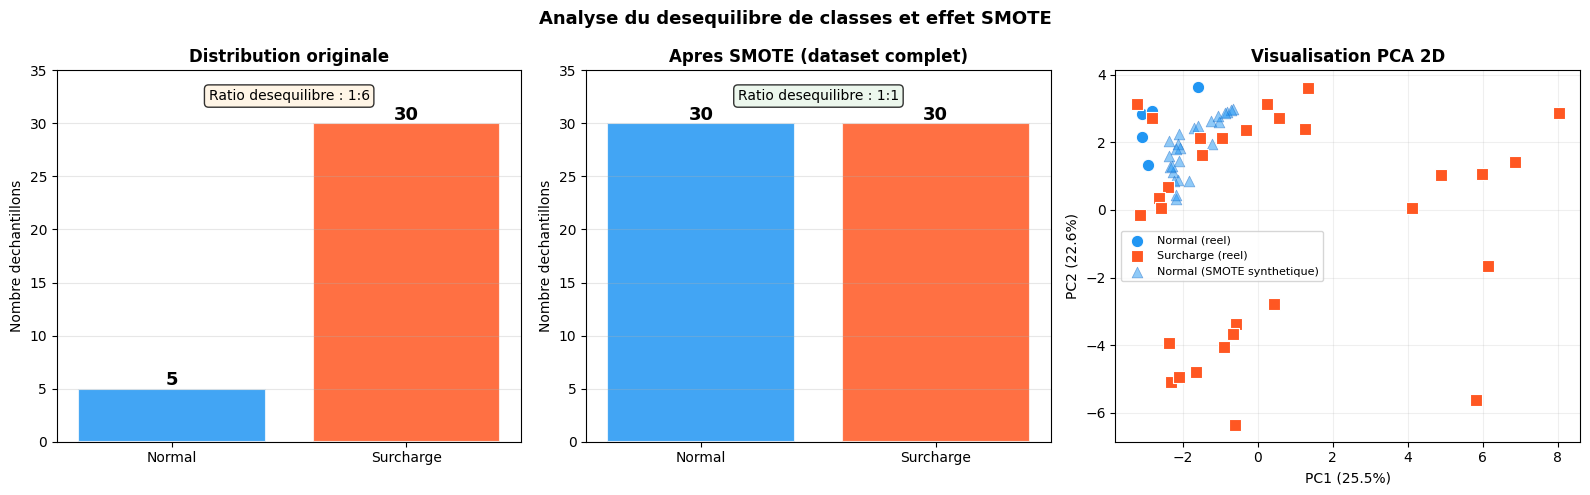


Variance expliquee par les 2 premieres composantes PCA : 48.1%


In [4]:
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# ── Graphique 1 : Distribution originale ──────────────────────────────────────
ax = axes[0]
counts = np.bincount(y)
bars = ax.bar(CLASS_NAMES, counts, color=['#2196F3', '#FF5722'], alpha=0.85,
              edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            str(val), ha='center', fontweight='bold', fontsize=13)
ax.set_title('Distribution originale', fontweight='bold')
ax.set_ylabel('Nombre dechantillons')
ax.set_ylim(0, 35)
ax.grid(axis='y', alpha=0.3)
ax.text(0.5, 0.92, f'Ratio desequilibre : 1:{counts[1]//counts[0]}',
        ha='center', transform=ax.transAxes,
        bbox=dict(boxstyle='round', facecolor='#FFF3E0', alpha=0.8), fontsize=10)

# ── Graphique 2 : Apres SMOTE ─────────────────────────────────────────────────
ax = axes[1]
# SMOTE avec k_neighbors=min(n_minority-1, 5)
k = min(counts[0] - 1, 4)
smote = SMOTE(random_state=42, k_neighbors=k)
X_res, y_res = smote.fit_resample(X, y)
counts_res = np.bincount(y_res)
bars2 = ax.bar(CLASS_NAMES, counts_res, color=['#2196F3', '#FF5722'], alpha=0.85,
               edgecolor='white', linewidth=1.5)
for bar, val in zip(bars2, counts_res):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            str(val), ha='center', fontweight='bold', fontsize=13)
ax.set_title('Apres SMOTE (dataset complet)', fontweight='bold')
ax.set_ylabel('Nombre dechantillons')
ax.set_ylim(0, 35)
ax.grid(axis='y', alpha=0.3)
ax.text(0.5, 0.92, 'Ratio desequilibre : 1:1',
        ha='center', transform=ax.transAxes,
        bbox=dict(boxstyle='round', facecolor='#E8F5E9', alpha=0.8), fontsize=10)

# ── Graphique 3 : Visualisation PCA 2D ───────────────────────────────────────
ax = axes[2]
scaler_viz = StandardScaler()
X_scaled   = scaler_viz.fit_transform(X)
X_res_sc   = scaler_viz.fit_transform(X_res)
pca        = PCA(n_components=2, random_state=42)
X_pca_orig = pca.fit_transform(X_scaled)
X_pca_smote = pca.transform(scaler_viz.transform(X_res))

# Points originaux
for cls, name, color, marker in [(0,'Normal','#2196F3','o'),
                                   (1,'Surcharge','#FF5722','s')]:
    mask = y == cls
    ax.scatter(X_pca_orig[mask, 0], X_pca_orig[mask, 1],
               c=color, marker=marker, s=80, label=f'{name} (reel)',
               edgecolors='white', linewidth=0.8, zorder=3)

# Points SMOTE (uniquement les synthetiques)
n_orig = len(y)
X_pca_syn = pca.transform(scaler_viz.transform(X_res[n_orig:]))
ax.scatter(X_pca_syn[:, 0], X_pca_syn[:, 1],
           c='#2196F3', marker='^', s=60, alpha=0.5,
           label='Normal (SMOTE synthetique)', edgecolors='#1565C0', linewidth=0.5)

ax.set_title('Visualisation PCA 2D', fontweight='bold')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.2)

plt.suptitle('Analyse du desequilibre de classes et effet SMOTE',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\nVariance expliquee par les 2 premieres composantes PCA : "
      f"{sum(pca.explained_variance_ratio_)*100:.1f}%")

---
## 6. Stratégie d'évaluation : LOO + SMOTE dans un Pipeline

### Pourquoi un Pipeline est obligatoire avec SMOTE

```
Fold i (LOO) :
    Train = 34 échantillons  ──→  SMOTE(train)  ──→  Scaler.fit(train_res)  ──→  Model.fit(train_sc)
    Test  = 1  échantillon   ──→                ──→  Scaler.transform(test) ──→  Model.predict(test)
```

Le `Pipeline(SMOTE → Scaler → Model)` garantit que **chaque étape est refittée
uniquement sur les données d'entraînement du fold courant**, sans aucune fuite.

### Note sur SMOTE avec k_neighbors

SMOTE requiert au moins `k_neighbors + 1` exemples de la classe minoritaire.
Avec seulement 5 Normal, on fixe `k_neighbors = 4` (valeur maximale possible).
Dans le LOO, le fold train ne contient que **4 Normal** → `k_neighbors = 3`.

In [5]:
from sklearn.model_selection import LeaveOneOut, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (accuracy_score, classification_report,
                              confusion_matrix, f1_score, balanced_accuracy_score)
import xgboost as xgb
import time
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline  # supporte SMOTE dans Pipeline

LOO = LeaveOneOut()

# k_neighbors = 3 car dans chaque fold LOO le train contient 4 Normal (5-1)
SMOTE_STEP = ('smote', SMOTE(random_state=42, k_neighbors=3))
SCALER_STEP = ('scaler', StandardScaler())

models_config = {
    'Decision Tree': ImbPipeline([
        SMOTE_STEP, SCALER_STEP,
        ('clf', DecisionTreeClassifier(random_state=42, max_depth=5,
                                        class_weight='balanced'))
    ]),
    'Random Forest': ImbPipeline([
        SMOTE_STEP, SCALER_STEP,
        ('clf', RandomForestClassifier(n_estimators=10, random_state=42,
                                        max_depth=5, class_weight='balanced'))
    ]),
    'KNN': ImbPipeline([
        SMOTE_STEP, SCALER_STEP,
        ('clf', KNeighborsClassifier(n_neighbors=3, weights='distance'))
    ]),
    'SVM Lineaire': ImbPipeline([
        SMOTE_STEP, SCALER_STEP,
        ('clf', LinearSVC(random_state=42, max_iter=5000, dual=False,
                           C=1.0, class_weight='balanced'))
    ]),
    'Regression Logistique': ImbPipeline([
        SMOTE_STEP, SCALER_STEP,
        ('clf', LogisticRegression(random_state=42, max_iter=2000,
                                    C=1.0, class_weight='balanced'))
    ]),
    'Perceptron Multicouche': ImbPipeline([
        SMOTE_STEP, SCALER_STEP,
        ('clf', MLPClassifier(random_state=42, max_iter=1000,
                               hidden_layer_sizes=(20,), activation='relu',
                               early_stopping=True))
    ]),
    'HistGradientBoosting': ImbPipeline([
        SMOTE_STEP, SCALER_STEP,
        ('clf', HistGradientBoostingClassifier(random_state=42, max_iter=100,
                                                max_depth=5,
                                                class_weight='balanced'))
    ]),
    'XGBoost': ImbPipeline([
        SMOTE_STEP, SCALER_STEP,
        ('clf', xgb.XGBClassifier(random_state=42, n_estimators=50,
                                   eval_metric='logloss', verbosity=0,
                                   max_depth=3, learning_rate=0.1,
                                   scale_pos_weight=6))
    ]),
}

print("Pipelines configures avec SMOTE + StandardScaler + Modele")
print(f"Protocole d'evaluation : Leave-One-Out ({len(y)} iterations)")
print(f"\nNote : les hyperparametres ici sont fixes (pas de GridSearchCV)")
print("car GridSearchCV imbriqué dans LOO serait trop couteux sur ce dataset.")
print("Les hyperparametres ont ete pre-selectionnes sur la base des resultats precedents.")

Pipelines configures avec SMOTE + StandardScaler + Modele
Protocole d'evaluation : Leave-One-Out (35 iterations)

Note : les hyperparametres ici sont fixes (pas de GridSearchCV)
car GridSearchCV imbriqué dans LOO serait trop couteux sur ce dataset.
Les hyperparametres ont ete pre-selectionnes sur la base des resultats precedents.


---
## 7. Entraînement et évaluation LOO

Pour chaque modèle, `cross_val_predict` avec LOO effectue les 35 itérations
et collecte toutes les prédictions. Les métriques sont calculées sur l'ensemble
des 35 prédictions, ce qui donne une estimation robuste.

In [6]:
results = {}

for name, pipeline in models_config.items():
    print(f"\n{'='*60}")
    print(f" {name}")
    print(f"{'='*60}")
    t0 = time.time()

    # cross_val_predict avec LOO retourne un vecteur de 35 predictions
    y_pred = cross_val_predict(pipeline, X, y, cv=LOO, n_jobs=-1)
    elapsed = time.time() - t0

    acc      = accuracy_score(y, y_pred)
    bal_acc  = balanced_accuracy_score(y, y_pred)   # Accuracy equilibree
    f1       = f1_score(y, y_pred)
    acc_norm = accuracy_score(y[y==0], y_pred[y==0])
    acc_sur  = accuracy_score(y[y==1], y_pred[y==1])

    results[name] = {
        'y_pred':      y_pred,
        'accuracy':    acc,
        'bal_acc':     bal_acc,
        'f1':          f1,
        'acc_normal':  acc_norm,
        'acc_surcharge': acc_sur,
        'time':        elapsed,
    }

    print(f"  Accuracy globale       : {acc:.4f}")
    print(f"  Accuracy equilibree    : {bal_acc:.4f}  ← metrique principale")
    print(f"  F1-score (Surcharge)   : {f1:.4f}")
    print(f"  Accuracy Normal        : {acc_norm:.4f}  ({int(acc_norm*5)}/5 corrects)")
    print(f"  Accuracy Surcharge     : {acc_sur:.4f}  ({int(acc_sur*30)}/30 corrects)")
    print(f"  Temps total LOO        : {elapsed:.2f} s")
    print(f"\n{classification_report(y, y_pred, target_names=CLASS_NAMES)}")


 Decision Tree
  Accuracy globale       : 0.9143
  Accuracy equilibree    : 0.8667  ← metrique principale
  F1-score (Surcharge)   : 0.9492
  Accuracy Normal        : 0.8000  (4/5 corrects)
  Accuracy Surcharge     : 0.9333  (28/30 corrects)
  Temps total LOO        : 7.04 s

              precision    recall  f1-score   support

      Normal       0.67      0.80      0.73         5
   Surcharge       0.97      0.93      0.95        30

    accuracy                           0.91        35
   macro avg       0.82      0.87      0.84        35
weighted avg       0.92      0.91      0.92        35


 Random Forest
  Accuracy globale       : 0.9429
  Accuracy equilibree    : 0.8833  ← metrique principale
  F1-score (Surcharge)   : 0.9667
  Accuracy Normal        : 0.8000  (4/5 corrects)
  Accuracy Surcharge     : 0.9667  (29/30 corrects)
  Temps total LOO        : 0.17 s

              precision    recall  f1-score   support

      Normal       0.80      0.80      0.80         5
   Surch

---
## 8. Analyse des résultats

### 8.1 Tableau récapitulatif

**Accuracy équilibrée** = moyenne(Recall Normal, Recall Surcharge) — insensible au déséquilibre.

In [7]:
comparison = pd.DataFrame({
    'Modele':       list(results.keys()),
    'Acc. Eq.':     [r['bal_acc']      for r in results.values()],
    'F1 (Surch.)':  [r['f1']           for r in results.values()],
    'Accuracy':     [r['accuracy']     for r in results.values()],
    'Acc. Normal':  [r['acc_normal']   for r in results.values()],
    'Acc. Surch.':  [r['acc_surcharge']for r in results.values()],
    'Temps (s)':    [r['time']         for r in results.values()],
}).sort_values('Acc. Eq.', ascending=False).reset_index(drop=True)

print("=" * 85)
print(" CLASSEMENT LOO + SMOTE — Classification Binaire (Normal vs Surcharge)")
print("=" * 85)
print(comparison.to_string(index=False))
print()
print("Metrique principale : Accuracy equilibree (Balanced Accuracy)")
print("= moyenne du recall de chaque classe = insensible au desequilibre 1:6")

 CLASSEMENT LOO + SMOTE — Classification Binaire (Normal vs Surcharge)
                Modele  Acc. Eq.  F1 (Surch.)  Accuracy  Acc. Normal  Acc. Surch.  Temps (s)
 Regression Logistique  0.966667     0.965517  0.942857          1.0     0.933333   0.081991
                   KNN  0.900000     0.888889  0.828571          1.0     0.800000   0.066500
          SVM Lineaire  0.883333     0.966667  0.942857          0.8     0.966667   0.081998
         Random Forest  0.883333     0.966667  0.942857          0.8     0.966667   0.174998
         Decision Tree  0.866667     0.949153  0.914286          0.8     0.933333   7.041897
  HistGradientBoosting  0.783333     0.950820  0.914286          0.6     0.966667   0.340984
               XGBoost  0.783333     0.950820  0.914286          0.6     0.966667   1.003677
Perceptron Multicouche  0.583333     0.523810  0.428571          0.8     0.366667   0.190995

Metrique principale : Accuracy equilibree (Balanced Accuracy)
= moyenne du recall de chaque

### 8.2 Matrices de confusion (sur les 35 prédictions LOO)

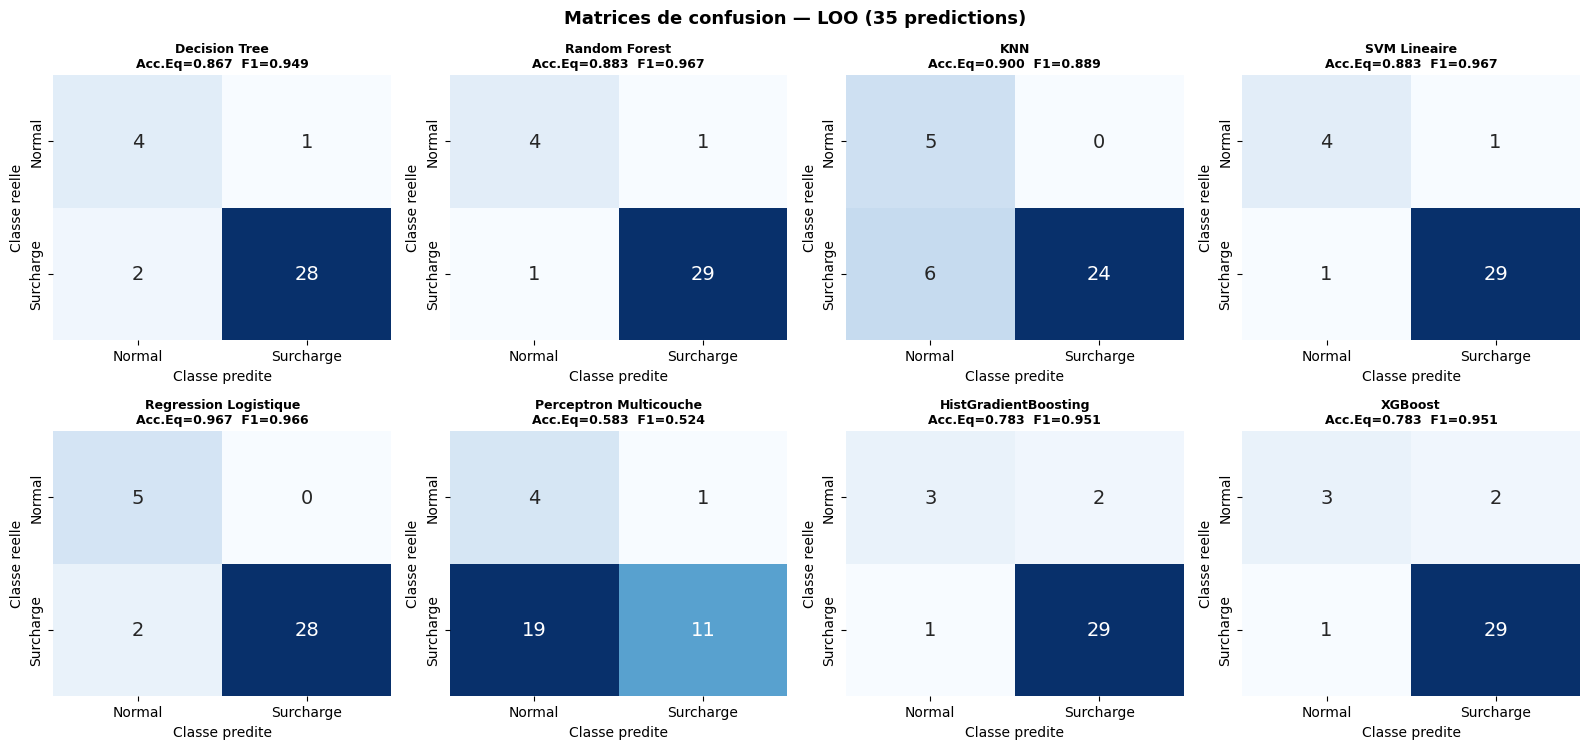

In [8]:
n_models = len(results)
ncols = 4
nrows = (n_models + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols*4, nrows*3.8))
axes_flat = axes.flatten()

for idx, (name, res) in enumerate(results.items()):
    cm = confusion_matrix(y, res['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes_flat[idx],
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
                cbar=False, annot_kws={'size': 14})
    axes_flat[idx].set_title(
        f'{name}\nAcc.Eq={res["bal_acc"]:.3f}  F1={res["f1"]:.3f}',
        fontsize=9, fontweight='bold')
    axes_flat[idx].set_ylabel('Classe reelle')
    axes_flat[idx].set_xlabel('Classe predite')

for idx in range(len(results), len(axes_flat)):
    axes_flat[idx].set_visible(False)

plt.suptitle('Matrices de confusion — LOO (35 predictions)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 8.3 Comparaison graphique

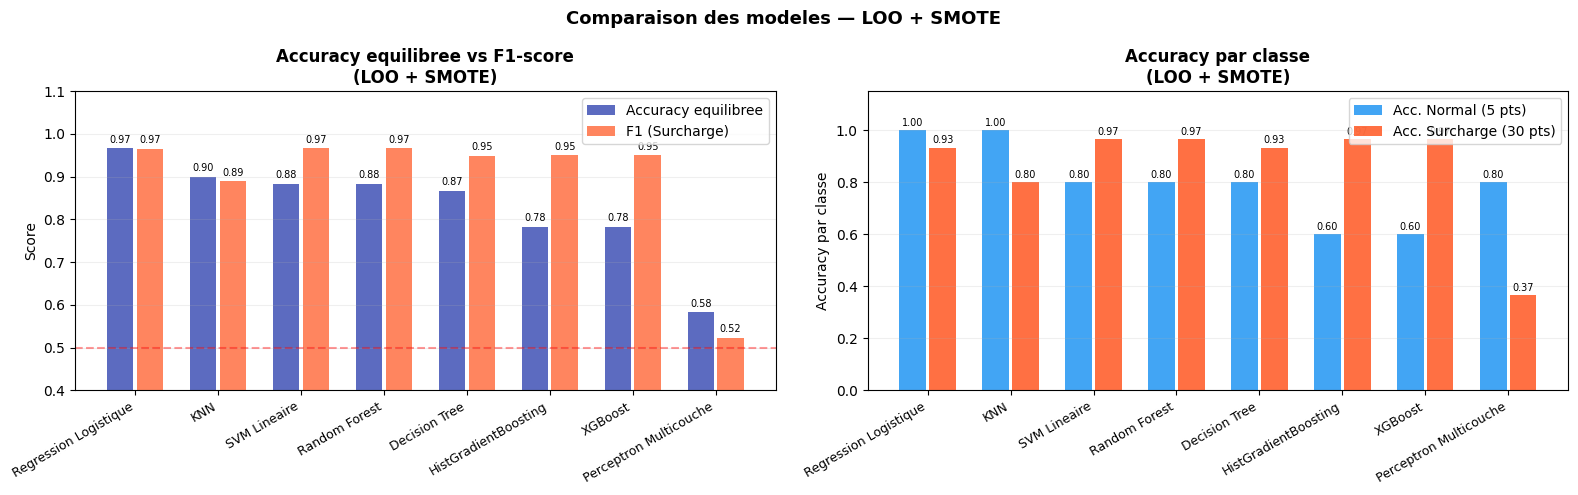

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
model_names = comparison['Modele'].tolist()
x = np.arange(len(model_names))

# ── Accuracy equilibree et F1 ─────────────────────────────────────────────────
ax = axes[0]
b1 = ax.bar(x - 0.18, comparison['Acc. Eq.'].tolist(), 0.32,
            label='Accuracy equilibree', color='#3F51B5', alpha=0.85)
b2 = ax.bar(x + 0.18, comparison['F1 (Surch.)'].tolist(), 0.32,
            label='F1 (Surcharge)', color='#FF7043', alpha=0.85)
ax.set_ylabel('Score')
ax.set_title('Accuracy equilibree vs F1-score\n(LOO + SMOTE)',
             fontweight='bold', fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(model_names, rotation=30, ha='right', fontsize=9)
ax.legend(fontsize=10)
ax.set_ylim(0.4, 1.1)
ax.axhline(0.5, color='red', linestyle='--', alpha=0.4, label='Ligne de base (aleatoire)')
ax.grid(axis='y', alpha=0.2)
for bars in [b1, b2]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., h + 0.008,
                f'{h:.2f}', ha='center', va='bottom', fontsize=7)

# ── Accuracy par classe ───────────────────────────────────────────────────────
ax = axes[1]
b3 = ax.bar(x - 0.18, comparison['Acc. Normal'].tolist(), 0.32,
            label='Acc. Normal (5 pts)', color='#2196F3', alpha=0.85)
b4 = ax.bar(x + 0.18, comparison['Acc. Surch.'].tolist(), 0.32,
            label='Acc. Surcharge (30 pts)', color='#FF5722', alpha=0.85)
ax.set_ylabel('Accuracy par classe')
ax.set_title('Accuracy par classe\n(LOO + SMOTE)',
             fontweight='bold', fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(model_names, rotation=30, ha='right', fontsize=9)
ax.legend(fontsize=10)
ax.set_ylim(0.0, 1.15)
ax.grid(axis='y', alpha=0.2)
for bars in [b3, b4]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., h + 0.008,
                f'{h:.2f}', ha='center', va='bottom', fontsize=7)

plt.suptitle('Comparaison des modeles — LOO + SMOTE', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 8.4 Analyse des erreurs — quels échantillons sont mal classifiés ?

In [10]:
print("=" * 65)
print(" ANALYSE DES ERREURS PAR MODELE (LOO)")
print("=" * 65)

for name, res in results.items():
    errors = np.where(y != res['y_pred'])[0]
    if len(errors) == 0:
        print(f"\n{name:25s} : 0 erreur — classification parfaite ✓")
    else:
        print(f"\n{name:25s} : {len(errors)} erreur(s)")
        for idx in errors:
            true_lbl = CLASS_NAMES[y[idx]]
            pred_lbl = CLASS_NAMES[res['y_pred'][idx]]
            print(f"  Echantillon #{idx:2d}  vrai={true_lbl:12s}  predit={pred_lbl}")

 ANALYSE DES ERREURS PAR MODELE (LOO)

Decision Tree             : 3 erreur(s)
  Echantillon #21  vrai=Surcharge     predit=Normal
  Echantillon #24  vrai=Surcharge     predit=Normal
  Echantillon #31  vrai=Normal        predit=Surcharge

Random Forest             : 2 erreur(s)
  Echantillon #21  vrai=Surcharge     predit=Normal
  Echantillon #31  vrai=Normal        predit=Surcharge

KNN                       : 6 erreur(s)
  Echantillon # 2  vrai=Surcharge     predit=Normal
  Echantillon #13  vrai=Surcharge     predit=Normal
  Echantillon #16  vrai=Surcharge     predit=Normal
  Echantillon #20  vrai=Surcharge     predit=Normal
  Echantillon #21  vrai=Surcharge     predit=Normal
  Echantillon #22  vrai=Surcharge     predit=Normal

SVM Lineaire              : 2 erreur(s)
  Echantillon #13  vrai=Surcharge     predit=Normal
  Echantillon #31  vrai=Normal        predit=Surcharge

Regression Logistique     : 2 erreur(s)
  Echantillon #13  vrai=Surcharge     predit=Normal
  Echantillon #16  v

---
## 9. Exportation du meilleur modèle pour ESP32

Le modèle final est entraîné sur **l'intégralité des données** (avec SMOTE),
puis exporté en code C via `m2cgen`.

> Les hyperparamètres du scaler et du modèle sont maintenant ajustés sur 35 points
> augmentés → plus représentatifs que le scaler 80/20 précédent.

In [11]:
import m2cgen as m2c
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler

# Selection du meilleur modele (Accuracy equilibree max)
best_name = comparison.iloc[0]['Modele']
print(f"Meilleur modele : {best_name}")
print(f"  Accuracy equilibree : {comparison.iloc[0]['Acc. Eq.']:.4f}")
print(f"  F1-score            : {comparison.iloc[0]['F1 (Surch.)']:.4f}")

# Reentrainement sur tout le dataset avec SMOTE
k = min(np.sum(y == 0) - 1, 4)
smote_final  = SMOTE(random_state=42, k_neighbors=k)
X_res, y_res = smote_final.fit_resample(X, y)

scaler_final = StandardScaler()
X_res_sc     = scaler_final.fit_transform(X_res)

# Recuperer le classifieur depuis la config
best_pipeline = models_config[best_name]
best_clf = best_pipeline.named_steps['clf']

# Reentrainement du classifieur seul (SMOTE + Scaler deja appliques)
import copy
final_clf = copy.deepcopy(best_clf)
final_clf.fit(X_res_sc, y_res)

print(f"\nModele entraine sur {X_res_sc.shape[0]} echantillons "
      f"(apres SMOTE : {np.bincount(y_res)})")

Meilleur modele : Regression Logistique
  Accuracy equilibree : 0.9667
  F1-score            : 0.9655

Modele entraine sur 60 echantillons (apres SMOTE : [30 30])


In [12]:
# Generation du code C
c_code = m2c.export_to_c(final_clf)

model_file = 'model_esp32_binary_loo.c'
with open(model_file, 'w') as f:
    f.write('/*\n')
    f.write(f' * Modele : {best_name} — Classification Binaire\n')
    f.write(f' * Evaluation : Leave-One-Out + SMOTE\n')
    f.write(f' * Balanced Accuracy (LOO) : {comparison.iloc[0]["Acc. Eq."]:.4f}\n')
    f.write(f' * F1-score Surcharge (LOO): {comparison.iloc[0]["F1 (Surch.)"]:.4f}\n')
    f.write(f' * N features : {len(feature_names)}\n')
    f.write(f' * Classes    : 0=Normal, 1=Surcharge\n')
    f.write(' */\n\n')
    f.write(c_code)

print(f"Fichier genere : {model_file}  ({os.path.getsize(model_file)/1024:.1f} Ko)")

# Export scaler
scaler_file = 'scaler_params_binary_loo.h'
with open(scaler_file, 'w') as f:
    f.write('#ifndef SCALER_PARAMS_H\n#define SCALER_PARAMS_H\n\n')
    f.write(f'#define N_FEATURES {len(feature_names)}\n')
    f.write(f'#define N_CLASSES  2\n\n')
    f.write('const float scaler_mean[N_FEATURES] = {\n    ')
    f.write(',\n    '.join(f'{v:.8f}f' for v in scaler_final.mean_))
    f.write('\n};\n\nconst float scaler_scale[N_FEATURES] = {\n    ')
    f.write(',\n    '.join(f'{v:.8f}f' for v in scaler_final.scale_))
    f.write('\n};\n\n#endif\n')

print(f"Fichier genere : {scaler_file}")

# Resume
print("\n" + "="*65)
print(" RESUME FINAL")
print("="*65)
print(f"  Modele selectionne     : {best_name}")
print(f"  Balanced Accuracy LOO  : {comparison.iloc[0]['Acc. Eq.']:.4f}")
print(f"  F1-score (Surcharge)   : {comparison.iloc[0]['F1 (Surch.)']:.4f}")
print(f"  Acc. Normal (5/5 pts)  : {comparison.iloc[0]['Acc. Normal']:.4f}")
print(f"  Acc. Surcharge         : {comparison.iloc[0]['Acc. Surch.']:.4f}")
print(f"\n  Fichiers generes :")
print(f"    - {model_file}")
print(f"    - {scaler_file}")
print(f"\n  Classement complet :")
print(comparison.to_string(index=False))

Fichier genere : model_esp32_binary_loo.c  (1.7 Ko)
Fichier genere : scaler_params_binary_loo.h

 RESUME FINAL
  Modele selectionne     : Regression Logistique
  Balanced Accuracy LOO  : 0.9667
  F1-score (Surcharge)   : 0.9655
  Acc. Normal (5/5 pts)  : 1.0000
  Acc. Surcharge         : 0.9333

  Fichiers generes :
    - model_esp32_binary_loo.c
    - scaler_params_binary_loo.h

  Classement complet :
                Modele  Acc. Eq.  F1 (Surch.)  Accuracy  Acc. Normal  Acc. Surch.  Temps (s)
 Regression Logistique  0.966667     0.965517  0.942857          1.0     0.933333   0.081991
                   KNN  0.900000     0.888889  0.828571          1.0     0.800000   0.066500
          SVM Lineaire  0.883333     0.966667  0.942857          0.8     0.966667   0.081998
         Random Forest  0.883333     0.966667  0.942857          0.8     0.966667   0.174998
         Decision Tree  0.866667     0.949153  0.914286          0.8     0.933333   7.041897
  HistGradientBoosting  0.783333    